In [2]:
from graphviz import Digraph

# Create directed graph
dot = Digraph("MDP_Flowchart", format="png")

dot.attr(rankdir="LR", fontsize="14", labelloc="t")
dot.attr(label="Markov Decision Process (MDP) Flowchart")

# ----------------------------
# States with Expected Rewards
# ----------------------------
dot.node(
    "S1",
    "State S1\nEIR(A1)=2.8\nEIR(A2)=0.0",
    shape="box",
    style="filled",
    fillcolor="lightblue"
)

dot.node(
    "S2",
    "State S2\nEIR(A1)=3.1\nEIR(A2)=2.6",
    shape="box",
    style="filled",
    fillcolor="lightgreen"
)

dot.node(
    "S3",
    "State S3\nEIR(A1)=3.6\nEIR(A2)=-0.6",
    shape="box",
    style="filled",
    fillcolor="lightcoral"
)

# ----------------------------
# Action A1 (Green)
# ----------------------------
dot.edge("S1", "S2",
         label="A1\nP=0.6\nR=5",
         color="green")

dot.edge("S1", "S3",
         label="A1\nP=0.2\nR=-1",
         color="green")

dot.edge("S2", "S1",
         label="A1\nP=0.7\nR=3",
         color="green")

dot.edge("S2", "S3",
         label="A1\nP=0.5\nR=2",
         color="green")

dot.edge("S3", "S1",
         label="A1\nP=0.9\nR=4",
         color="green")

dot.edge("S3", "S2",
         label="A1\nP=0.4\nR=0",
         color="green")

# ----------------------------
# Action A2 (Red)
# ----------------------------
dot.edge("S1", "S2",
         label="A2\nP=0.4\nR=10",
         color="red")

dot.edge("S1", "S3",
         label="A2\nP=0.8\nR=-5",
         color="red")

dot.edge("S2", "S1",
         label="A2\nP=0.3\nR=7",
         color="red")

dot.edge("S2", "S3",
         label="A2\nP=0.5\nR=1",
         color="red")

dot.edge("S3", "S1",
         label="A2\nP=0.1\nR=6",
         color="red")

dot.edge("S3", "S2",
         label="A2\nP=0.6\nR=-2",
         color="red")

# ----------------------------
# Legend
# ----------------------------
with dot.subgraph(name="cluster_legend") as c:
    c.attr(label="Legend", color="black")

    c.node("L1", "Blue Box = State", shape="box",
           style="filled", fillcolor="lightblue")

    c.node("L2", "Green Edge = Action A1",
           shape="plaintext")

    c.node("L3", "Red Edge = Action A2",
           shape="plaintext")

    c.node("L4", "Edge Label:\nAction\nProbability (P)\nReward (R)",
           shape="note")

# Display
dot

ModuleNotFoundError: No module named 'graphviz'

In [3]:
!pip install graphviz


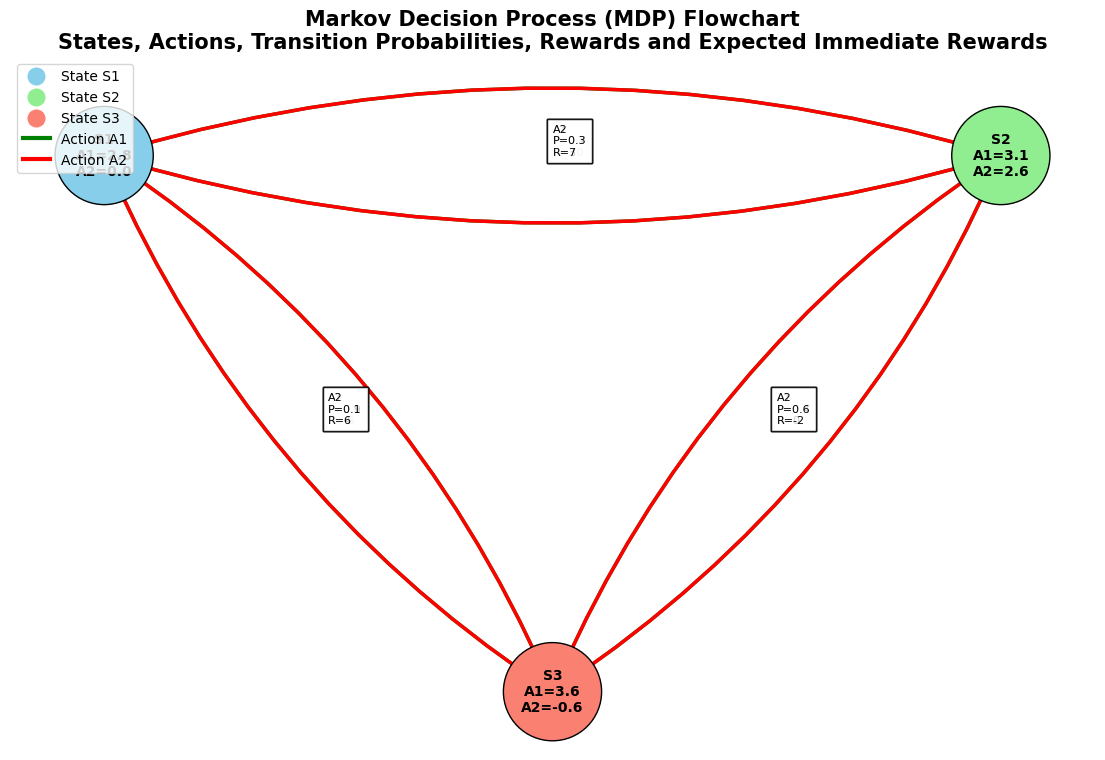

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -----------------------------
# Create Directed Graph
# -----------------------------
G = nx.MultiDiGraph()

# -----------------------------
# States
# -----------------------------
states = ["S1", "S2", "S3"]

# Expected Immediate Rewards
eir = {
    "S1": {"A1": 2.8, "A2": 0.0},
    "S2": {"A1": 3.1, "A2": 2.6},
    "S3": {"A1": 3.6, "A2": -0.6}
}

# Add Nodes
for state in states:
    G.add_node(
        state,
        label=f"{state}\nA1={eir[state]['A1']}\nA2={eir[state]['A2']}"
    )

# -----------------------------
# Transition Data
# -----------------------------
transitions = [

("S1","S2","A1",0.6,5),
("S1","S2","A2",0.4,10),

("S1","S3","A1",0.2,-1),
("S1","S3","A2",0.8,-5),

("S2","S1","A1",0.7,3),
("S2","S1","A2",0.3,7),

("S2","S3","A1",0.5,2),
("S2","S3","A2",0.5,1),

("S3","S1","A1",0.9,4),
("S3","S1","A2",0.1,6),

("S3","S2","A1",0.4,0),
("S3","S2","A2",0.6,-2)

]

# Add Edges
for s, ns, a, p, r in transitions:
    G.add_edge(
        s,
        ns,
        action=a,
        probability=p,
        reward=r
    )

# -----------------------------
# Flowchart Positions
# -----------------------------
pos = {
    "S1": (0,1),
    "S2": (3,1),
    "S3": (1.5,-1)
}

plt.figure(figsize=(14,9))

# -----------------------------
# Draw Nodes
# -----------------------------
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=5000,
    node_color=["skyblue","lightgreen","salmon"],
    edgecolors="black"
)

labels = {
    n: G.nodes[n]["label"]
    for n in G.nodes()
}

nx.draw_networkx_labels(
    G,
    pos,
    labels,
    font_size=10,
    font_weight="bold"
)

# -----------------------------
# Draw Edges
# -----------------------------
for s, ns, key, data in G.edges(keys=True, data=True):

    color = "green" if data["action"]=="A1" else "red"

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(s,ns)],
        edge_color=color,
        arrows=True,
        arrowsize=25,
        width=2.5,
        connectionstyle="arc3,rad=0.15"
    )

# -----------------------------
# Edge Labels
# -----------------------------
edge_labels = {}

for s, ns, key, data in G.edges(keys=True, data=True):

    edge_labels[(s,ns,key)] = (
        f"{data['action']}\n"
        f"P={data['probability']}\n"
        f"R={data['reward']}"
    )

for (u,v,k), label in edge_labels.items():

    x = (pos[u][0] + pos[v][0]) / 2
    y = (pos[u][1] + pos[v][1]) / 2

    plt.text(
        x,
        y,
        label,
        fontsize=8,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            alpha=0.8
        )
    )

# -----------------------------
# Legend
# -----------------------------
legend_items = [

Line2D([0],[0],
marker='o',
color='w',
label='State S1',
markerfacecolor='skyblue',
markersize=14),

Line2D([0],[0],
marker='o',
color='w',
label='State S2',
markerfacecolor='lightgreen',
markersize=14),

Line2D([0],[0],
marker='o',
color='w',
label='State S3',
markerfacecolor='salmon',
markersize=14),

Line2D([0],[0],
color='green',
lw=3,
label='Action A1'),

Line2D([0],[0],
color='red',
lw=3,
label='Action A2')

]

plt.legend(
    handles=legend_items,
    loc="upper left",
    fontsize=10
)

# -----------------------------
# Title
# -----------------------------
plt.title(
    "Markov Decision Process (MDP) Flowchart\n"
    "States, Actions, Transition Probabilities, Rewards and Expected Immediate Rewards",
    fontsize=15,
    weight="bold"
)

plt.axis("off")
plt.show()